## Part B: Data Assessment

*Suggested time: ~60 minutes*

You have been warned that `patients.csv` and `encounters.csv` contain data quality issues.

Now that data has been loaded, please assess these files using your preferred approach, and provide **written answers** to the following questions:

**B1. Identify at least 3 data quality issues in each of `patients.csv` and `encounters.csv`. For each issue:**
- What is the issue?
- Is it **blocking** (will cause incorrect analytics results) or **non-blocking** (cosmetic / should be flagged but won't break downstream outputs)?
- How would you handle it in your pipeline?

**B2. The file `encounters_schema_change_batch.csv` has a different schema. How would you unify this with the main encounters data?**

----

In [ ]:
!pip3 install google-cloud-bigquery-storage

In [84]:
from constants import GCP_PROJECT, BQ_RAW_DATASET                                                                                                              
from google.cloud import bigquery                                                                                                                              
import pandas as pd                                                                                                                                            

pd.set_option('display.float_format', '{:.2f}'.format) # Remove scientific notation

pd.set_option('display.max_columns', None)                                                                                                                     
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', None)

bq_client = bigquery.Client(project=GCP_PROJECT)

def query(sql: str) -> pd.DataFrame:
    return bq_client.query(sql).to_dataframe()

# "Patients" issues

In [6]:
patients = query(f"SELECT * FROM `{BQ_RAW_DATASET}.patients`")
print(f"Shape: {patients.shape}")
patients.head(2)

Shape: (1193, 25)


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,b5667894-5282-4265-8a2d-bd933cdbc9ec,2002-10-25,None,999-86-9900,S99979392,None,None,Logan497,Torphy630,None,None,None,white,hispanic,M,Winthrop Massachusetts US,654 Anderson Mall Suite 39,Abington,Massachusetts,Plymouth County,2351.0,42.126612,-70.922218,423200.02,3092.28
1,2e3f986b-0894-4e57-a893-5d7eb334c829,2015-06-14,None,999-29-6195,None,None,None,Twanna669,Hand679,None,None,None,white,nonhispanic,F,Cambridge Massachusetts US,301 Denesik Branch,Adams,Massachusetts,Berkshire County,1220.0,42.610513,-73.159738,115877.12,1915.72


### Duplicates unique IDs

In [ ]:
# Total duplicate rows (excluding first occurrence)
duplicate_rows = patients['Id'].duplicated().sum()

# Number of unique IDs that are duplicated
duplicate_unique_ids = (
    patients.loc[patients['Id'].duplicated(keep=False), 'Id']
    .nunique()
)

# Distribution: how many IDs appear 2 times, 3 times, etc.
id_counts = patients['Id'].value_counts()
duplicate_distribution = (
    id_counts[id_counts > 1]
    .value_counts()
    .sort_index()
)

print(f"Duplicate rows (excluding first occurrence): {duplicate_rows}")
print(f"Unique IDs that are duplicated: {duplicate_unique_ids}")

print("\nDuplicate distribution (records per ID):")
for dup_size, count in duplicate_distribution.items():
    print(f"{count} unique IDs appear {dup_size} times")

Duplicate rows (excluding first occurrence): 22
Unique IDs that are duplicated: 21

Duplicate distribution (records per ID):
20 unique IDs appear 2 times
1 unique IDs appear 3 times


### Null values

In [ ]:
null_counts = patients.isnull().sum()
null_counts[null_counts > 0]

DEATHDATE     995
DRIVERS       213
PASSPORT      273
PREFIX        244
SUFFIX       1181
MAIDEN        858
MARITAL       385
ZIP           551
dtype: int64

### Birth and death dates logic

In [11]:
# Check that birthdates and deathdates make logical sense
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'], errors='coerce')
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'], errors='coerce')

future_births = patients[patients['BIRTHDATE'] > pd.Timestamp.now()]
print(f"Birthdates in the future: {len(future_births)}")

deceased = patients[patients['DEATHDATE'].notna()]
death_before_birth = deceased[deceased['DEATHDATE'] < deceased['BIRTHDATE']]
print(f"Deathdate before birthdate: {len(death_before_birth)}")

Birthdates in the future: 23
Deathdate before birthdate: 27


### Latitude and Longitude logic

In [ ]:
# Massachusetts coordinates: Lat ~41-43 (positive), Lon ~-69 to -73 (negative)                                                                                                
# Swapped rows will have negative Lat and positive Lon. Massachusetts seems to be affected                                                                                    
swapped_coords = patients[(patients['LAT'] < 0) & (patients['LON'] > 0)]
print(f"Rows with swapped Lat/Lon: {len(swapped_coords)}")
swapped_coords[['Id', 'CITY', 'STATE', 'LAT', 'LON']].head(50)

Rows with swapped Lat/Lon: 23


,Id,CITY,STATE,LAT,LON
7,7a397d12-fe12-47c4-9b55-69f054c71fa5,Amherst,Massachusetts,-72.54,42.39
39,f6499733-1d98-4d73-a168-1ef765ad827f,Boston,Massachusetts,-71.01,42.28
49,e112cedd-a98e-489e-abb0-875420d40397,Brookline,Massachusetts,-71.17,42.30
76,f065dd0d-8cf7-4289-87a1-b296ef64be1b,Fall River,Massachusetts,-71.04,41.62
97,6d3480e3-45a3-4f7c-b97e-0901dc6c8b05,Holbrook,Massachusetts,-71.03,42.21
134,e188fafe-c1bb-45dc-9627-4ff4e4bc0ec0,Natick,Massachusetts,-71.34,42.26
154,6d4312d1-0663-474b-bd30-b0e00dd7dbc7,Peabody,Massachusetts,-70.99,42.53
178,4054b69b-2082-4ce7-ae96-0c10f7da3020,Seekonk,Massachusetts,-71.34,41.85
280,46d3a308-7383-47ff-802c-c97bfd727720,Boston,Massachusetts,-71.13,42.30
365,af08878c-08dc-4938-aebd-cd5da315c479,Chelmsford,Massachusetts,-71.40,42.62


### Corrupt SSN values

In [101]:
# Check for corrupted SSN values (expected format: 999-99-9999)
import re
ssn_pattern = re.compile(r'^\d{3}-\d{2}-\d{4}$')
invalid_ssn = patients[~patients['SSN'].apply(lambda x: bool(ssn_pattern.match(str(x))) if pd.notna(x) else True)]
print(f"Invalid SSN values: {len(invalid_ssn)}")
invalid_ssn[['Id', 'SSN']].head(50)

Invalid SSN values: 23


,Id,SSN
2,8141abe7-08b5-4415-99dd-00c801d48098,BZhvWaXH6K2`
8,cde60f66-8df0-4bc6-8056-2ec5ba2cd638,pFCiRc.)D.Ca
69,df72fdee-e347-4c77-a3bb-074655dd67be,sHrF*'H-2-ZU
84,d1639077-59f3-401f-a058-2ad70502f93f,tVu(&a/P
90,05cdf25a-7da5-4a7b-b721-8e63d2e3b6ec,coUNEhE+kk~!
105,33189b5c-5919-4e99-8b62-89b225531eac,lEv0!
120,25d6cb75-fac8-4007-a065-819121f4bab9,^2/iXW/
363,a2e8d9a7-0eb0-4441-adb5-7cc720380f4e,&G)b^}o^'I?R
481,f0f6572b-1588-4828-bb8b-e3148692e536,"r$""lgot="
531,173c7abc-b19b-4533-aa53-7156b53df51f,L3u6a}


## "Encounters" issues

In [85]:
encounters = query(f"SELECT * FROM `{BQ_RAW_DATASET}.encounters`")
print(f"Shape: {encounters.shape}")
encounters.head(2)

Shape: (53356, 15)


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,e38ae964-57ef-43f7-b1a5-8a11674bdb1d,2011-04-25T16:07:39Z,2011-04-26T18:07:39Z,d9f90c91-2e37-40ca-a574-89b33a120d16,f1fbcbfb-fcfa-3bd2-b7f4-df20f1b3c3a4,446d1609-858f-3a54-8a52-0c4eacedd00e,047f6ec3-6215-35eb-9608-f9dda363a44c,inpatient,305408004,Admission to surgical department,129.16,129.16,69.16,NaN,None
1,2bc9dfee-2f51-4a69-9a93-18027de7558c,2016-02-23T19:28:39Z,2016-02-24T21:28:39Z,88587157-4de8-4459-b6d4-fd571b847575,5d4b9df1-93ae-3bc9-b680-03249990e558,af01a385-31d3-3c77-8fdb-2867fe88df2f,047f6ec3-6215-35eb-9608-f9dda363a44c,inpatient,305408004,Admission to surgical department,129.16,129.16,69.16,NaN,None


### Null values

In [ ]:
null_counts_enc = encounters.isnull().sum()
null_counts_enc[null_counts_enc > 0]

REASONCODE           39578
REASONDESCRIPTION    39578
dtype: int64

### START and STOP dates logic

In [88]:
encounters['START'] = pd.to_datetime(encounters['START'], errors='coerce')
encounters['STOP'] = pd.to_datetime(encounters['STOP'], errors='coerce')
encounters['duration_hrs'] = (encounters['STOP'] - encounters['START']).dt.total_seconds() / 3600

negative_duration = encounters[encounters['duration_hrs'] < 0]
print(f"Encounters with STOP before START: {len(negative_duration)}")

null_start = encounters[encounters['START'].isna()]
null_stop = encounters[encounters['STOP'].isna()]
print(f"Encounters with null START: {len(null_start)}")
print(f"Encounters with null STOP: {len(null_stop)}")

Encounters with STOP before START: 1043
Encounters with null START: 0
Encounters with null STOP: 0


### START dates before 100 years ago
100 years before 2020 as this is the max date in the data

In [104]:
encounters['STOP'].max()

'2020-04-28T19:28:37Z'

Total encounters from before 1920: 1084


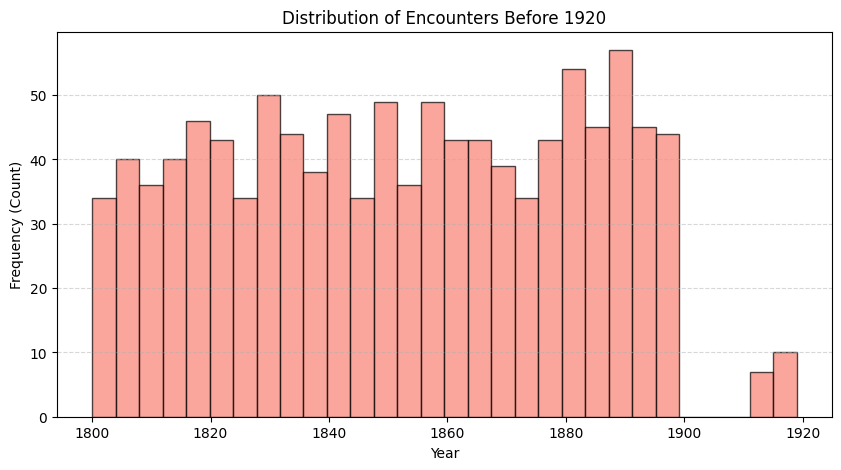

In [103]:
import matplotlib.pyplot as plt

# Threshold (100 years before 2020)
threshold_year = 2020 - 100
cutoff_date = pd.Timestamp(year=threshold_year, month=1, day=1, tz='UTC')

# Convert and Filter
encounters['START'] = pd.to_datetime(encounters['START'], errors='coerce', utc=True)
old_encounters = encounters[encounters['START'] < cutoff_date].copy()

count_old = len(old_encounters)
print(f"Total encounters from before {threshold_year}: {count_old}")

if count_old > 0:
    # Extract year
    years = old_encounters['START'].dt.year
    
    plt.figure(figsize=(10, 5))
    plt.hist(years, bins=30, color='salmon', edgecolor='black', alpha=0.7)
    
    plt.title(f"Distribution of Encounters Before {threshold_year}")
    plt.xlabel("Year")
    plt.ylabel("Frequency (Count)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
else:
    print(f"No records found before {threshold_year}.")

## Patients + Encounters

In [29]:
# Orphaned patient references. Referential integrity check between `patients` (parent table) and `encounters` (child table). 
# Shows where an "encounter" references a patient ID that does not exist in the `patients` table.
patient_ids = set(patients['Id'].unique()) # get all valid IDs
orphaned = encounters[~encounters['PATIENT'].isin(patient_ids)] # Get all `encounters` patients not part of `patients` patients
print(f"Encounters referencing non-existent patients: {len(orphaned)}")
orphaned

Encounters referencing non-existent patients: 10


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,duration_hrs
8386,6d39264d-5013-472a-988c-f6e7c0ed9ed7,2016-06-04 10:41:08+00:00,2016-06-04 11:55:08+00:00,9a42ff58-0fdf-4d50-b76a-38214126c7fc,f4e7709c-02f6-37ca-aeea-8247d74e88e7,4d0bb3a1-8259-3749-a330-e9c17879d81a,4d71f845-a6a9-3c39-b242-14d25ef86a8d,ambulatory,371883000,Orphan encounter 6,129.16,129.16,64.16,NaN,None,1.23
12816,9e702077-7651-45e8-94b6-974bc31b13ba,2020-04-17 21:09:52+00:00,2020-04-17 21:51:52+00:00,ec289b95-012e-4528-9646-355cf30b8007,ecc51621-0af3-3b35-ac3e-8b1e34022e92,326937ff-4a1a-3771-91cc-97a5dc9f34d0,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,ambulatory,185349003,Orphan encounter 3,129.16,129.16,59.16,NaN,None,0.70
12817,f0bd7028-0f6b-4072-af58-d1bc96d57ef4,2003-09-07 13:25:58+00:00,2003-09-07 13:40:58+00:00,0785ad63-bc8c-4936-805b-741ffce7c73a,308b5efa-a9c2-3728-b1ff-d29c5f060731,cb868a81-474c-3547-bf2d-d88a03795bb5,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,urgentcare,702927004,Orphan encounter 7,129.16,129.16,0.00,NaN,None,0.25
18894,ff592918-82e5-4042-b293-5332e9069eb6,2020-02-09 08:06:12+00:00,2020-02-09 08:36:12+00:00,69953665-63ec-421c-9746-006aab785074,58fe1815-1e8a-38ed-a91a-17d4ef18c8d8,5c0cfe05-f379-3013-8c5c-1452f420d019,6e2f1a2d-27bd-3701-8d08-dae202c58632,wellness,162673000,Orphan encounter 10,129.16,129.16,129.16,NaN,None,0.50
18895,6aef765b-5e89-4bab-a613-74c29d2af430,1970-05-30 17:27:52+00:00,1970-05-30 17:57:52+00:00,e9233a11-59c6-4cc0-8de9-5456f7bb9173,4a1c5788-d5c9-3306-a691-d5ab7725c49d,5c28fd64-d526-3e5b-8565-fd3aaef6972f,6e2f1a2d-27bd-3701-8d08-dae202c58632,wellness,162673000,Orphan encounter 4,129.16,129.16,54.16,NaN,None,0.50
18896,dfa8f7fb-b761-4dcf-ab27-726a6021b7d3,1968-02-20 00:42:46+00:00,1968-03-05 00:42:46+00:00,7db3f1ed-b612-402f-aa3a-99cb294b1350,49318f80-bd8b-3fc7-a096-ac43088b0c12,680f4af2-775d-34c4-b213-28791e0813e3,6e2f1a2d-27bd-3701-8d08-dae202c58632,ambulatory,185345009,Orphan encounter 5,129.16,129.16,54.16,446096008.00,Perennial allergic rhinitis,336.00
36836,a88a8bec-333e-4c6e-afae-e053963d25ed,1879-10-16 22:42:00+00:00,2004-09-05 13:55:58+00:00,57880022-1a73-4773-822d-b484a0c240c4,3a2242e0-de37-303b-bdfc-e160c7eae518,c49ac45b-cd50-3bee-86ed-122e3883e25b,7caa7254-5050-3b5e-9eae-bd5ea30e809c,wellness,162673000,Orphan encounter 2,129.16,129.16,89.16,NaN,None,1094751.23
36837,6ed35382-5c60-47a7-a5e7-d1d36240c696,2019-11-10 07:02:15+00:00,2019-11-10 07:32:15+00:00,fd4c03f8-6717-4f62-bf6d-abfe55051a43,869ba21d-a974-3260-9752-4d1ba8d12f28,0d16624e-1fa9-39ad-989b-857b7bfc08c4,7caa7254-5050-3b5e-9eae-bd5ea30e809c,wellness,162673000,Orphan encounter 9,129.16,129.16,129.16,NaN,None,0.50
46003,d22986f2-6311-4f66-8e3f-42d3dc295ab2,2020-01-31 14:19:13+00:00,2020-01-31 14:47:13+00:00,c7adeee9-857e-4a09-8899-5ebd673afd10,d692e283-0833-3201-8e55-4f868a9c0736,f4eb93d1-9187-3cfb-83a4-6d9cd77f7df6,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Orphan encounter 1,129.16,129.16,0.00,NaN,None,0.47
46004,0516e105-100a-4f83-ac86-49d23da86c44,2013-05-16 02:58:09+00:00,2013-05-16 03:13:09+00:00,69639bb3-ad6d-400f-8136-a77aefbd1f20,476a6290-43dd-32db-872f-9c7ad4f04d56,a2c63d36-8d8a-3a8e-9178-478bfe43c60d,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,410620009,Orphan encounter 8,129.16,129.16,0.00,NaN,None,0.25


## B2.
The file `encounters_schema_change_batch.csv` has a different schema. How would you unify this with the main encounters data?

In [90]:
encounters = query(f"SELECT * FROM `{BQ_RAW_DATASET}.encounters`") # Reload for clean start. Data is small so this is fine.
schema_batch = query(f"SELECT * FROM `{BQ_RAW_DATASET}.encounters_schema_change_batch`")
print(f"Shape: {schema_batch.shape}")
print(f"\nColumns: {list(schema_batch.columns)}")
print(f"\nSource systems: {schema_batch['SOURCE_SYSTEM'].value_counts().to_dict()}")

Shape: (200, 16)

Columns: ['Id', 'PATIENT', 'ENCOUNTER_TYPE', 'CODE', 'DESCRIPTION', 'START', 'STOP', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'SOURCE_SYSTEM']

Source systems: {'EPIC_PROD': 117, 'CERNER_LEGACY': 83}


In [91]:
# Inspect schema
common = encounters.columns.intersection(schema_batch.columns)
only_enc = encounters.columns.difference(schema_batch.columns)
only_batch = schema_batch.columns.difference(encounters.columns)

print(f"Shared: {len(common)} | Encounters Only: {list(only_enc)} | Batch Only: {list(only_batch)}")

# Check for Dtype mismatches that will cause issues
mismatches = pd.concat([encounters[common].dtypes, schema_batch[common].dtypes], axis=1, keys=['Enc', 'Batch'])
mismatches = mismatches[mismatches['Enc'] != mismatches['Batch']]

if not mismatches.empty:
    print("\nDtype Mismatches Found:")
    print(mismatches)

Shared: 14 | Encounters Only: ['ENCOUNTERCLASS'] | Batch Only: ['ENCOUNTER_TYPE', 'SOURCE_SYSTEM']

Dtype Mismatches Found:
          Enc    Batch
START  object    Int64
STOP   object  float64


In [68]:
# Standardise 'encounters' (Strings to Datetime)
for col in ['START', 'STOP']:
    encounters[col] = pd.to_datetime(encounters[col], errors='coerce', utc=True)

# Standardise 'schema_batch' (Milliseconds to Datetime)
for col in ['START', 'STOP']:
    schema_batch[col] = pd.to_datetime(schema_batch[col], unit='ms', errors='coerce', utc=True)

# Concatenate
unified_encounters = pd.concat([encounters, schema_batch], ignore_index=True)

# Add source flag for EDA
unified_encounters['data_source'] = (
    ['original'] * len(encounters) + ['batch'] * len(schema_batch)
)

# Filter out the 1800s noise
cutoff = pd.Timestamp('1900-01-01', tz='UTC')
unified_encounters = unified_encounters[unified_encounters['START'] >= cutoff]

print(f"Unification complete. Total rows: {len(unified_encounters)}")
print("Verified Date Ranges by Source:")
print(unified_encounters.groupby('data_source')['START'].agg(['min', 'max']))

Unification complete. Total rows: 52489
Verified Date Ranges by Source:
                                  min                       max
data_source                                                    
batch       1939-12-10 09:30:42+00:00 2020-04-20 01:04:01+00:00
original    1912-07-24 18:20:21+00:00 2020-04-30 10:57:30+00:00


In [94]:
# Check for overlap window
# Get boundaries
orig_min = unified_encounters.loc[unified_encounters['data_source'] == 'original', 'START'].min()
orig_max = unified_encounters.loc[unified_encounters['data_source'] == 'original', 'START'].max()
batch_min = unified_encounters.loc[unified_encounters['data_source'] == 'batch', 'START'].min()
batch_max = unified_encounters.loc[unified_encounters['data_source'] == 'batch', 'START'].max()

# Check for Overlap
overlap = (batch_min <= orig_max) and (batch_max >= orig_min)

if overlap:
    print(f"Overlap Detected: Both datasets share the window between {max(orig_min, batch_min)} and {min(orig_max, batch_max)}.")
else:
    if batch_min > orig_max:
        print(f"Continuation: Batch starts {batch_min - orig_max} after Original ends.")
    elif orig_min > batch_max:
        print(f"Pre-continuation: Batch ends {orig_min - batch_max} before Original starts.")

Overlap Detected: Both datasets share the window between 1939-12-10 09:30:42+00:00 and 2020-04-20 01:04:01+00:00.


In [97]:
# Create a 'Year-Month' column for grouping. Strip timezone info first to silence Pandas warnings about converting to PeriodArray/Index dropping timezone info
unified_encounters['year_month'] = unified_encounters['START'].dt.tz_localize(None).dt.to_period('M')

# Pivot to see record counts per month per source
monthly_counts = unified_encounters.groupby(['year_month', 'data_source']).size().unstack(fill_value=0)

# Show only the months where BOTH have data
overlap_months = monthly_counts[(monthly_counts['batch'] > 0) & (monthly_counts['original'] > 0)]

print(f"Months where both datasets are active: {len(overlap_months)}")
print(overlap_months.head())

Months where both datasets are active: 158
data_source  batch  original
year_month                  
1939-12          1         7
1946-06          1         4
1953-02          1         9
1958-08          1         9
1959-01          1         5


Date ranges by source:
                                  min                       max
data_source                                                    
batch       1939-12-10 09:30:42+00:00 2020-04-20 01:04:01+00:00
original    1912-07-24 18:20:21+00:00 2020-04-30 10:57:30+00:00


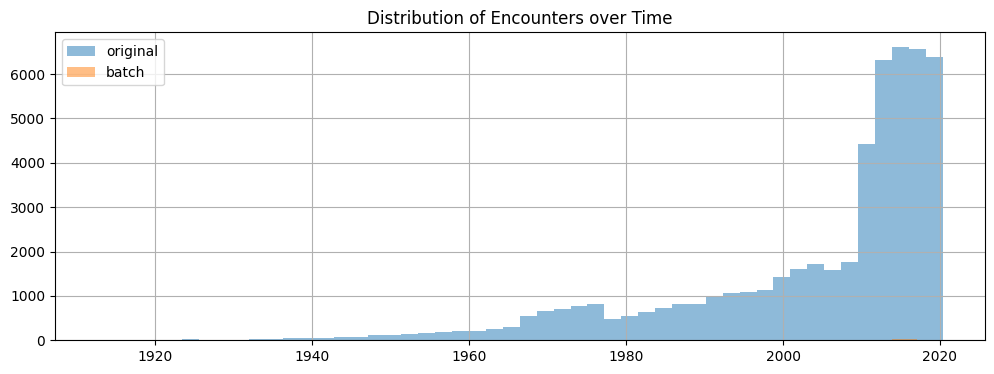

In [73]:
# Check date ranges per source
date_audit = unified_encounters.groupby('data_source')['START'].agg(['min', 'max'])
print("Date ranges by source:")
print(date_audit)

# Visualising the density of records over time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for source in unified_encounters['data_source'].unique():
    subset = unified_encounters[unified_encounters['data_source'] == source]
    subset['START'].hist(bins=50, alpha=0.5, label=source)

plt.title("Distribution of Encounters over Time")
plt.legend()
plt.show()